In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.random.rand(1000,1)
y = 0.5*x**3 - 5*x**2 + 5*np.sin(x*10)


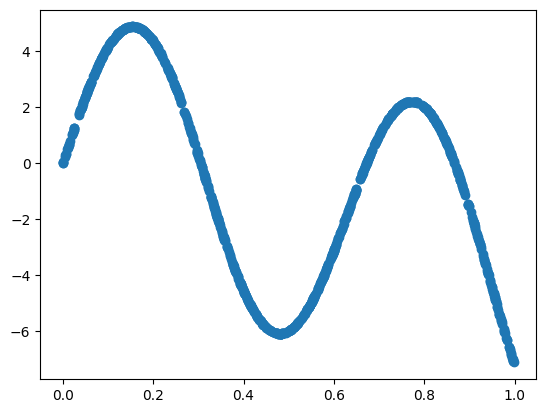

In [38]:
plt.scatter(x=x, y=y)

In [39]:
data = np.c_[x,y]

In [40]:
df = pd.DataFrame(data, columns=['X','Y'])
df

,X,Y
0,0.271955,1.688404
1,0.217891,3.871414
2,0.661835,-0.400571
3,0.633712,-1.611183
4,0.593461,-3.364252
...,...,...
995,0.610363,-2.641982
996,0.546407,-5.063943
997,0.249744,2.698526
998,0.343275,-2.004294


array([[<Axes: title={'center': 'X'}>, <Axes: title={'center': 'Y'}>]],
      dtype=object)

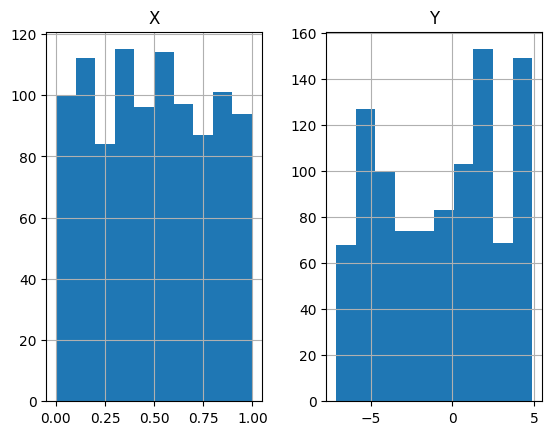

In [41]:
df.hist()

In [42]:
# Model de regressió lineal

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)  # 80% per a entrenament, 20% per a prova
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)  # Calcular l'Error Quadràtic Mitjà (MSE)
rmse = np.sqrt(mse)  # Calcular l'Arrel de l'Error Quadràtic Mitjà (RMSE)
r2 = r2_score(y_test, y_pred)  # Calcular el Coeficient de Determinació (R²)
intercept = model.intercept_[0]  # Obtenir el terme independent (intercepta)
coefficient = model.coef_[0][0]  # Obtenir el coeficient de la variable X
print(f"Equació del model: y = {coefficient:.4f}X + {intercept:.4f}")
print(f"MSE {mse:.2f} RMSE {rmse} R2 {r2}")

Equació del model: y = -5.7076X + 2.1500
MSE 10.89 RMSE 3.2997581526184847 R2 0.16398339694674768


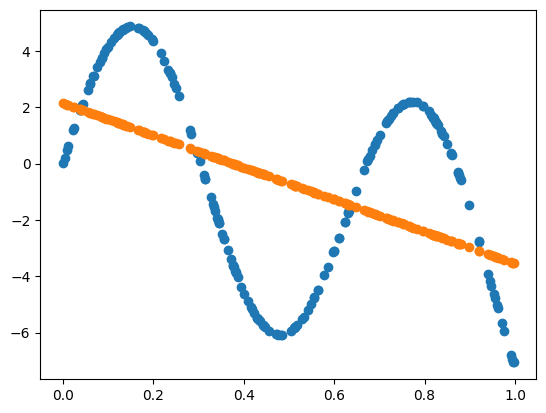

In [44]:
plt.scatter(x=X_test, y=y_test)
plt.scatter(x=X_test, y=y_pred)

In [45]:
# L'idea és crear una "xarxa neuronal" de 2 neurones d'entrada i una eixida. 
# LinealRegression té un error MSE per defecte i caldria modificar la seua funció
# d'error en funció del resultat total amb backpropagation
# Per tant, cal fer una regressió lineal manual amb una funció de loss personalitzada.

# Mirar si LinealRegression permet multi value o fan falta 2 
# Mirar si LinealRegression permet personalitzar la funcio de pérdua
# Mirar com connectar l'eixida de dos com a entrada d'una lineal regression
# Es podria fer un bucle en el que les dos neurones inicials fan una predicció aleatoria
# Generen un dataset de X1,X2 que passa a la segona capa i eixa es compara amb el resultat esperat. i es fa el backpropagation 

In [46]:
import numpy as np

# Dades fictícies
#X = np.array([[1.0], [2.0], [3.0], [4.0]])  # shape (N, 1)
#y = np.array([[2.0], [4.0], [6.0], [8.0]])  # shape (N, 1)
X = X_train
y = y_train


np.random.seed(42)
N = X.shape[0]

# 1. Inicialització de pesos
W1 = np.random.randn(1, 2)  # Capa 1: 1 entrada -> 2 neurones
b1 = np.zeros((1, 2))

W2 = np.random.randn(2, 1)  # Capa 2: 2 entrades -> 1 eixida
b2 = np.zeros((1, 1))

lr = 0.01

for epoch in range(1000):
    # --- PASSADA ENDAVANT (Forward Pass) ---
    h = np.dot(X, W1) + b1       # Output capa 1, shape (N, 2)
    y_pred = np.dot(h, W2) + b2  # Output capa 2, shape (N, 1)
    
    # --- CÀLCUL DE L'ERROR EN L'EIXIDA (Capa 2) ---
    delta2 = (y_pred - y) / N    # Gradient d'eixida, shape (N, 1)
    dW2 = np.dot(h.T, delta2)
    db2 = np.sum(delta2, axis=0, keepdims=True)
    
    # --- PROPAGACIÓ DE L'ERROR A LA CAPA OCULTA (Capa 1) ---
    delta1 = np.dot(delta2, W2.T) # Error atribuït a la capa 1, shape (N, 2)
    dW1 = np.dot(X.T, delta1)
    db1 = np.sum(delta1, axis=0, keepdims=True)
    
    # --- ACTUALITZACIÓ DE PESOS (SGD) ---
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

print("Pesos finals Capa 1 (W1):\n", W1)
print("Pesos finals Capa 2 (W2):\n", W2)

Pesos finals Capa 1 (W1):
 [[-0.01377539 -2.11733344]]
Pesos finals Capa 2 (W2):
 [[0.43117596]
 [2.68719542]]


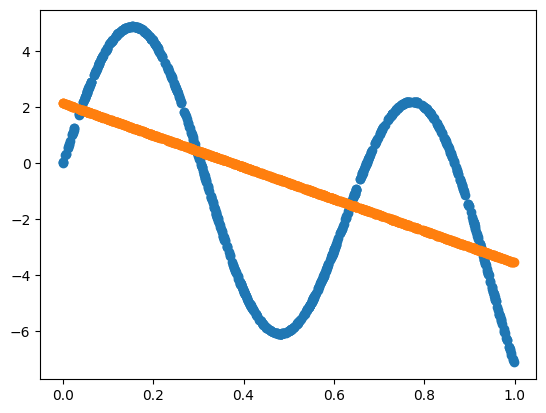

In [47]:
plt.scatter(x=X_train, y=y_train)
plt.scatter(x=X_train, y=y_pred)

In [52]:
import numpy as np

# Funció d'activació sigmoide i la seua derivada respecte a l'activació
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(a):
    # a = sigmoid(z), per tant d/dz sigmoid(z) = a * (1 - a)
    return a * (1 - a)

# Dades d'entrenament
X = X_train
y = y_train
np.random.seed(42)
N = X.shape[0]

# 1. Inicialització de pesos
W1 = np.random.randn(1, 5)  # Capa 1: 1 entrada -> 2 neurones
b1 = np.zeros((1, 5))

W2 = np.random.randn(5, 1)  # Capa 2: 2 entrades -> 1 eixida
b2 = np.zeros((1, 1))

lr = 0.1  # Taxa d'aprenentatge
epochs = 5000

for epoch in range(epochs):
    # --- PASSADA ENDAVANT (Forward Pass) ---
    z1 = np.dot(X, W1) + b1       # Entrada lineal a la capa 1
    a1 = sigmoid(z1)              # Activació Sigmoide: h = σ(z1)
    y_pred = np.dot(a1, W2) + b2  # Predicció final d'eixida (lineal)
    
    # --- PROPAGACIÓ CAP ENRERE (Backpropagation) ---
    # Gradient de la capa d'eixida
    delta2 = (y_pred - y) / N    # dL / dy_pred
    dW2 = np.dot(a1.T, delta2)
    db2 = np.sum(delta2, axis=0, keepdims=True)
    
    # Gradient de la capa oculta (APLICANT LA REGLA DE LA CADENA)
    # δ1 = (δ2 · W2^T) ⊙ σ'(z1)
    delta1 = np.dot(delta2, W2.T) * sigmoid_derivative(a1)
    dW1 = np.dot(X.T, delta1)
    db1 = np.sum(delta1, axis=0, keepdims=True)
    
    # --- ACTUALITZACIÓ DE PESOS ---
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

# Results
print("--- RESULTATS DE L'ENTRENAMENT ---")
#print("Prediccions finals (y_pred):\n", np.round(y_pred, 2))
#print("\nPesos finals Capa 1 (W1):\n", W1)
#print("Bias final Capa 1 (b1):\n", b1)
#print("\nPesos finals Capa 2 (W2):\n", W2)
#print("Bias final Capa 2 (b2):\n", b2)

--- RESULTATS DE L'ENTRENAMENT ---


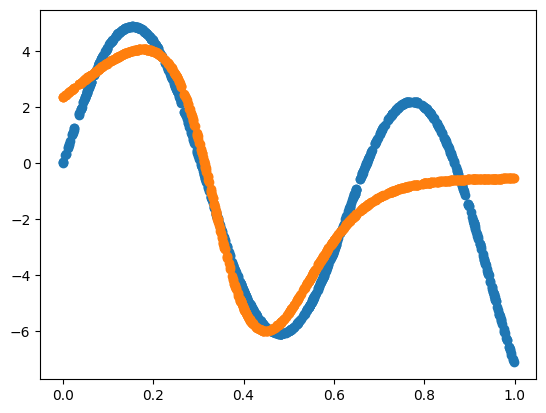

In [53]:
plt.scatter(x=X_train, y=y_train)
plt.scatter(x=X_train, y=y_pred)

Si no hi ha una funció d'activació no lineal entremig (com la sigmoide que vam afegir a l'últim exemple), **tota la xarxa continua sent estrictament lineal**, independentment de quantes capes o neurones hi posis.

Matemàticament, es pot demostrar fàcilment per què passa això combinant les equacions de les dues capes.

---

### La demostració pas a pas

Imagina la teva estructura exacta:

1. **Capa 1 (2 regressions lineals):** Rep la variable $x$ i genera dues sortides ($h_1, h_2$). En forma matricial:

$$h = x W_1 + b_1$$



*(on $x$ és $(N, 1)$, $W_1$ és $(1, 2)$ i $h$ és $(N, 2)$)*
2. **Capa 2 (1 regressió lineal que rep les 2 variables de $h$):**

$$\hat{y} = h W_2 + b_2$$



*(on $W_2$ és $(2, 1)$ i $\hat{y}$ és $(N, 1)$)*

Si ara **substitueixes** la primera equació dins de la segona:


$$\hat{y} = (x W_1 + b_1) W_2 + b_2$$

Aplicant la propietat distributiva de les matrius:


$$\hat{y} = x (W_1 W_2) + (b_1 W_2 + b_2)$$

### Què significa això en la pràctica?

* El producte de matrius $W_1 W_2$ dóna com a resultat un **únic nombre** (un pes efectiu equivalent $W_{\text{efectiu}}$).
* La suma $(b_1 W_2 + b_2)$ dóna un **únic biaix** ($b_{\text{efectiu}}$).

Per tant, l'equació final queda reduïda a:


$$\hat{y} = x \cdot W_{\text{efectiu}} + b_{\text{efectiu}}$$

Aquesta és l'equació clàssica d'una **única regressió lineal** ($y = mx + c$).

### Per què serveixen llavors les capes ocultes?

* **Sense activació no lineal:** Posar 2 capes (o 100 capes) lineals és matemàticament redundant; equival a fer exactament el mateix que faria un `LinearRegression` de Scikit-Learn de manera directa.
* **Amb activació no lineal (com la sigmoide):** En introduir $h = \sigma(x W_1 + b_1)$, **ja no es pot aplicar la propietat distributiva** per eliminar els parèntesis. Això trenca la linealitat i permet que la xarxa aprengui relacions complexes i corbes, que és el veritable propòsit del *deep learning*.

Això que descrius és un fenomen clàssic i molt il·lustratiu en el *machine learning*, conegut com a **sobreajust (*overfitting*)** i està relacionat amb la **capacitat** de la xarxa i la **inicialització** dels pesos.

El fet que hagis passat de 2 a 50 neurones a la capa oculta ha canviat dràsticament el comportament de la xarxa perquè ara tens molts més graus de llibertat (paràmetres per ajustar).

Analitzem què està passant en els dos casos, assumint que estàs utilitzant una funció d'activació no-lineal (com la sigmoide que vam veure anteriorment):

### 1. Per què amb 50 neurones "clava dos senos" i la resta queda recte?

Una xarxa neuronal amb una capa oculta i una activació no-lineal és un **aproximador universal de funcions**. Això vol dir que, teòricament, pot aproximar qualsevol funció contínua si té prou neurones.

Tanmateix, a la pràctica, l'aprenentatge depèn de l'algorisme d'optimització (SGD) i de les dades disponibles.

* **Excés de capacitat:** Amb 50 neurones, la xarxa té una capacitat enorme. Pot adaptar-se extremadament bé als punts de dades que té.
* **Comportament fora del rang d'entrenament (Extrapolació):** Les funcions d'activació com la sigmoide o la ReLU tenen un comportament "pla" o lineal quan els valors d'entrada (el producte $x \cdot W$) són molt grans o molt petits.
* Fora del rang on la xarxa ha estat entrenada, les neurones tendeixen a saturar-se i la sortida es torna lineal o constant.
* Per això, la xarxa pot ajustar-se a la forma sinusoïdal on té dades, però el seu comportament fora d'aquest rang (on no té exemples per aprendre) és imprevisible i sovint tendeix a una recta o una constant.



El resultat que descrius (ajustar-se als dos "senos" i després recte) és una manifestació que la xarxa ha après **de memòria** la forma local de les dades, però no ha capturat la tendència global subjacent.

### 2. Per què amb 2 neurones "ha aprés un poc"?

Amb només 2 neurones a la capa oculta, la xarxa té una **capacitat molt limitada**.

* Pot intentar ajustar una tendència general, com una línia recta amb una lleugera curvatura, però no té prous "punts d'inflexió" (la combinació de les formes sigmoides de les dues neurones) per reproduir una forma sinusoïdal complexa amb precisió.
* És un cas de **subajust (*underfitting*)**. La xarxa és massa simple per a la complexitat del problema.

### Com solucionar el sobreajust (Overfitting) amb 50 neurones?

Si vols utilitzar 50 neurones per obtenir una millor aproximació però evitar que s'adapti excessivament a les dades d'entrenament, has d'aplicar tècniques de regularització:

1. **Reduir la Taxa d'Aprenentatge (Learning Rate):** Si la taxa és molt alta, la xarxa pot oscil·lar i trobar solucions inestables. Prova de baixar-la (ex. de 0.1 a 0.01 o 0.001).
2. **Augmentar les Dades d'Entrenament:** La solució més efectiva. Si tens més dades, la xarxa no podrà memoritzar-les tan fàcilment i haurà de generalitzar.
3. **Regularització L1 o L2:** Aquesta tècnica penalitza els pesos grans de la xarxa, forçant-la a ser més simple i suau.
4. **Early Stopping:** Monitora l'error en un conjunt de validació (dades que no s'utilitzen per entrenar) i atura l'entrenament quan aquest error comença a augmentar, fins i tot si l'error d'entrenament segueix baixant.
5. **Dropout (Menys comú en regressió simple):** Apaga aleatòriament algunes neurones durant l'entrenament per evitar que la xarxa depengui massa d'una sola neurona.

**En resum:** Amb 50 neurones, la xarxa té potencial per aprendre la forma sinusoïdal, però l'entrenament no és òptim. El sobreajust s'evita utilitzant tècniques de regularització i, idealment, proporcionant més dades que representin correctament la funció que vols que aprengui.

Que amb més neurones tampoc millore del tot (o que faci comportaments estranys com clavar un parell de crestes i quedar-se completament pla) és un fenomen molt estudiat quan s'intenta entrenar una xarxa neuronal simple amb funcions cícliques com un si (*sine*).

Afegir més neurones a cegues no soluciona el problema a causa de com interactuen la matemàtica de les capes i l'algorisme d'optimització:

### 1. La saturació de la sigmoide (*Vanishing Gradients*)

Les funcions d'activació com la sigmoide tenen un comportament pla als extrems (quan l'entrada a la neurona és molt alta o molt baixa, la seva derivada cau pràcticament a zero).

* Si durant l'entrenament els pesos creixen massa, les neurones cauen en aquesta zona plana.
* Un cop una neurona es "satura", el seu gradient s'anul·la i **deixa d'aprendre per sempre**.
* Si poses 50 o 100 neurones, moltes d'elles s'encallaran en aquest estat inútil i la xarxa ignorarà bona part de les dades.

### 2. El conflicte geomètric (Sigmoide vs. Sinusoïdal)

Una sigmoide és una funció **monòtona** (té forma d'S, només puja o només baixa). En canvi, una funció sinusoïdal és **periòdica i oscil·la** constantment amunt i avall.

* Per simular una ona que puja i baixa utilitzant únicament peces formades per "S" estirades, la xarxa necessita combinar la posició i els pesos de les neurones amb una precisió quirúrgica.
* L'algorisme de descens pel gradient (*SGD*) s'enfronta a un paisatge d'error molt complex i sovint es conforma amb una solució mediocre (dibuixar un parell d'ones on hi ha més densitat de dades i deixar la resta pla) perquè trobar la combinació exacta de paràmetres per a tot el cicle és extremadament difícil.

### 3. El paisatge d'optimització i els mínims locals

En augmentar el nombre de neurones, augmentes dràsticament els graus de llibertat. Això no simplifica el problema, sinó que crea un espai de cerca ple de **mínims locals** on l'algorisme s'encalla fàcilment, incapaç d'arribar a la configuració global òptima.

---

### Què es pot fer per millorar-ho?

* **Normalització estricta:** Assegurar-te que tant la variable $X$ com la sortida $y$ estiguin escalades en un rang reduït (com de $-1$ a $1$). Si els valors d'entrada creixen lliurement, les capes interiors saturen les sigmoides des de la primera època.
* **Canviar de funció d'activació:** Provar alternatives com `Tanh` (que centra la sortida entre $-1$ i $1$) o `ReLU` sol ajudar a mantenir els gradients actius, tot i que aproximar ones pures amb xarxes neuronals estàndard continua sent un repte clàssic d'optimització.

---

Pots veure una anàlisi visual d'aquest comportament a [Training a neural network on the sine function](https://www.youtube.com/watch?v=srnGe1FqzOM&utm_source=gemini), on s'explica gràficament per què les xarxes neuronals estàndard pateixen tant per aproximar i generalitzar funcions sinusoïdals.